# Demo: Every Plot Type in the Default Lookup Table

When you call `.plot()` with no arguments, Symbulate inspects your simulated
data and picks a sensible **default** plot for it. The choice depends on two
things:

1. the **data configuration** — is it 1D or 2D, and is each variable
   discrete-ish or continuous-ish (decided by `classify_data`), and
2. the **sample size** — small (`n < 100`) or large.

Every `(configuration, size)` combination maps to one default plot plus a
short list of reasonable **alternatives** you can request with `type=`. This
notebook walks through each configuration, shows how the default changes as
the sample grows from small to large, and demonstrates each alternative.

The note printed under a default plot names the current plot and its
alternatives (shown here with `suggest=True` so it always appears).

## The lookup table at a glance

| Configuration | Small-n default | Small-n alternatives | Large-n default | Large-n alternatives |
|---|---|---|---|---|
| 1D discrete | dotplot | impulse, bar, ecdf | impulse | bar, hist, dotplot, ecdf |
| 1D continuous | rug | hist, density, box, ecdf | hist | density, rug, box, ecdf |
| 1D categorical | dotplot | impulse, bar | impulse | bar, dotplot |
| 2D discrete × discrete | scatter | tile, mosaic | tile | scatter, mosaic |
| 2D continuous × continuous | scatter | density2d, hist2d | hist2d | density2d, scatter |
| 2D mixed (discrete × continuous) | segmented_rug | tile, box, violin, segmented_density | tile | violin, box, segmented_density |

Each configuration has its own section below.

In [1]:
%matplotlib inline
from symbulate import *

## 1D discrete

A single numeric variable with relatively few distinct values — counts,
like `Binomial(10, 0.4)`. The default is a **dot plot** at small `n` (you
can see every observation) and an **impulse plot** at large `n` (one clean
stem per value).

**Small `n` → dot plot (default)**

Currently Showing: Dot Plot (Default)
Alternative Plots: Impulse Plot (type = "impulse"), Bar Chart (type = "bar"), ECDF Plot (type = "ecdf")


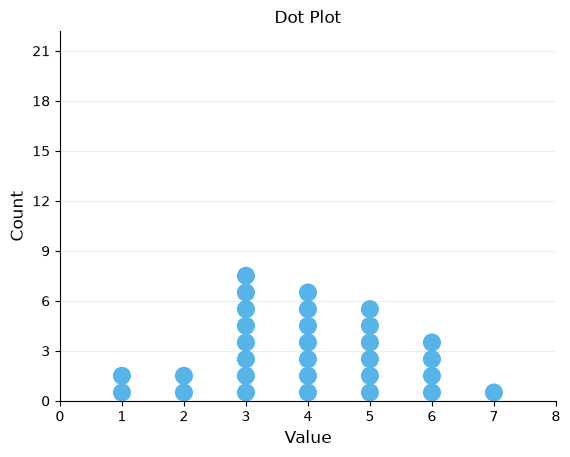

In [2]:
RV(Binomial(10, 0.4)).sim(30).plot(suggest=True)

**Large `n` → impulse plot (default)**

Currently Showing: Impulse Plot (Default)
Alternative Plots: Bar Chart (type = "bar"), Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


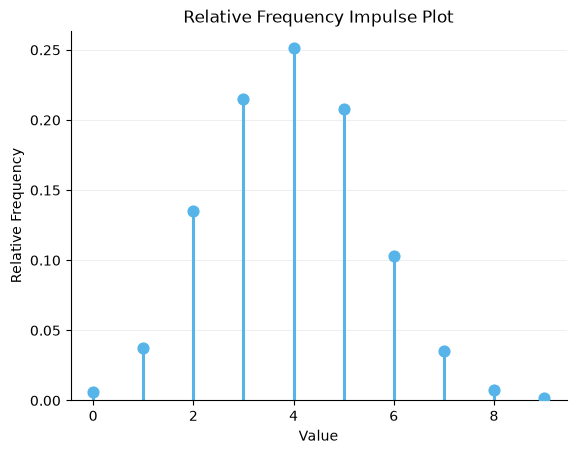

In [3]:
RV(Binomial(10, 0.4)).sim(2000).plot(suggest=True)

**Alternatives** (`bar`, `hist`, `ecdf`; `impulse` and `dotplot` are the defaults above)

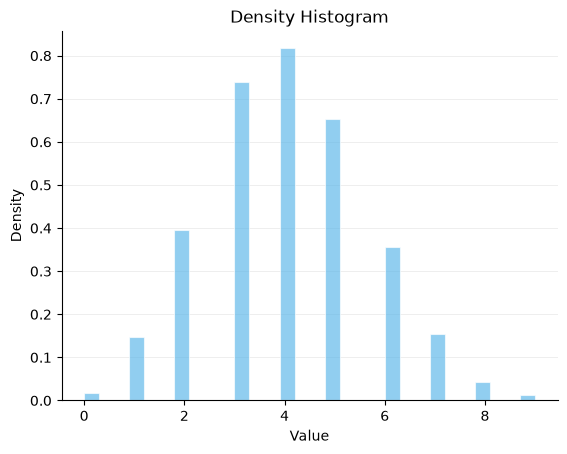

In [4]:
RV(Binomial(10, 0.4)).sim(2000).plot(type="bar")

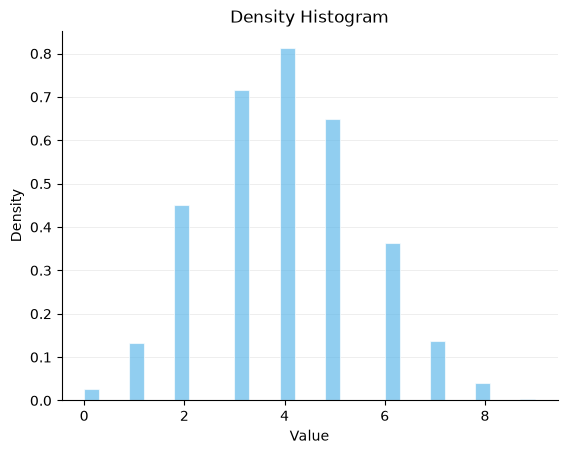

In [5]:
RV(Binomial(10, 0.4)).sim(2000).plot(type="hist")

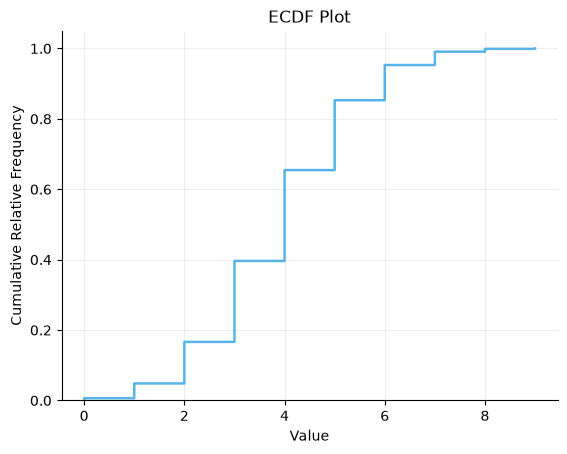

In [6]:
RV(Binomial(10, 0.4)).sim(2000).plot(type="ecdf")

## 1D continuous

A single numeric variable with many distinct values — e.g.
`Normal(0, 1)`. The default is a **rug plot** at small `n` (a tick per
observation on a number line) and a **histogram** at large `n`.

**Small `n` → rug plot (default)**

Currently Showing: Rug Plot (Default)
Alternative Plots: Histogram (type = "hist"), Density Plot (type = "density"), Box Plot (type = "box"), ECDF Plot (type = "ecdf")


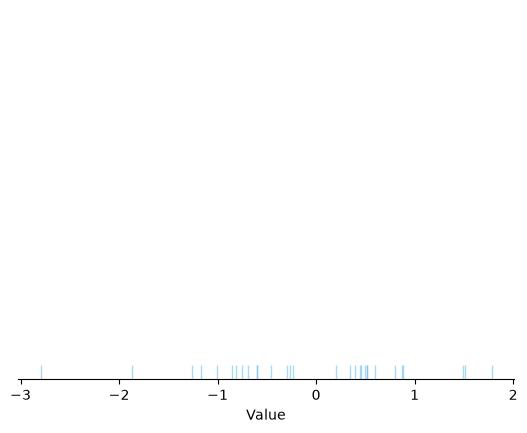

In [7]:
RV(Normal(0, 1)).sim(30).plot(suggest=True)

**Large `n` → histogram (default)**

Currently Showing: Histogram (Default)
Alternative Plots: Density Plot (type = "density"), Rug Plot (type = "rug"), Box Plot (type = "box"), ECDF Plot (type = "ecdf")


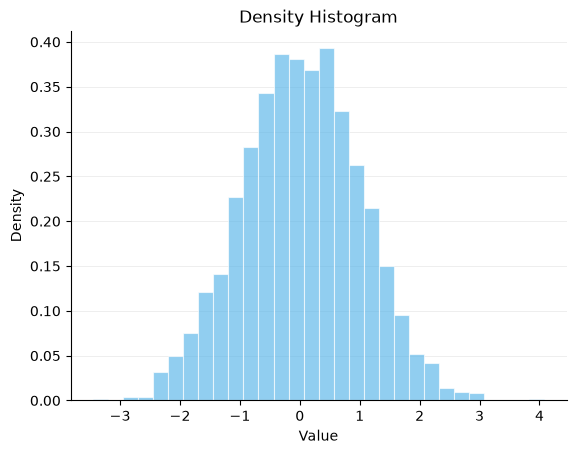

In [8]:
RV(Normal(0, 1)).sim(2000).plot(suggest=True)

**Alternatives** (`density`, `box`, `ecdf`; `rug` and `hist` are the defaults above)

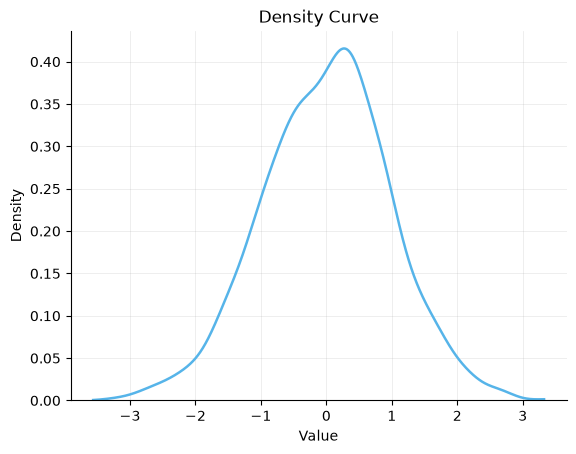

In [9]:
RV(Normal(0, 1)).sim(2000).plot(type="density")

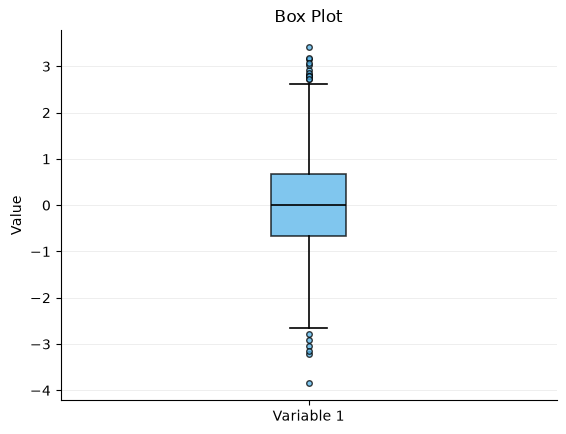

In [10]:
RV(Normal(0, 1)).sim(2000).plot(type="box")

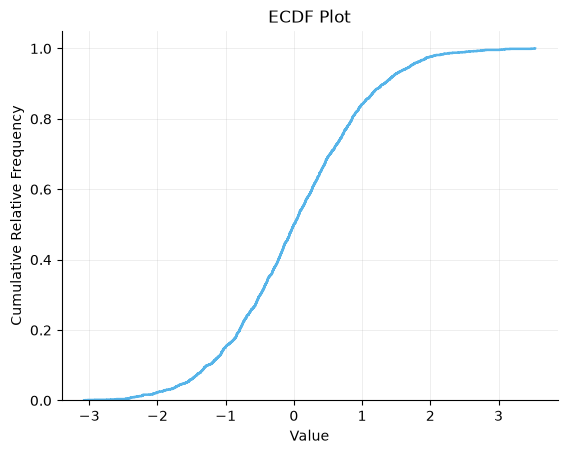

In [11]:
RV(Normal(0, 1)).sim(2000).plot(type="ecdf")

## 1D categorical

This configuration (string / label outcomes such as `"H"`/`"T"`) is
listed in the lookup table — default **dot plot** at small `n`, **impulse**
at large `n`, with `bar` as an alternative — but a random variable whose
outcomes are non-numeric can't currently be sent to `.plot()` directly
(`.plot()` expects numbers). Use `.tabulate()` to summarize categorical
outcomes for now; live categorical plotting is future work, which is why no
plot cells are shown here.

## 2D discrete × discrete

Two discrete variables, e.g. `Binomial(5, 0.4) * Binomial(5, 0.4)`. The
default is a **scatter** (with jitter) at small `n` and a **tile plot** at
large `n`, where color shows how often each cell occurred.

**Small `n` → scatter (default)**

Currently Showing: Scatter Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Mosaic Plot (type = "mosaic")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


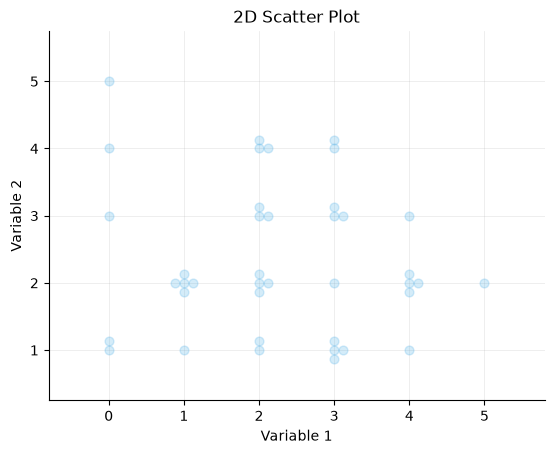

In [12]:
RV(Binomial(5, 0.4) * Binomial(5, 0.4)).sim(40).plot(suggest=True)

**Large `n` → tile plot (default)**

Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic")


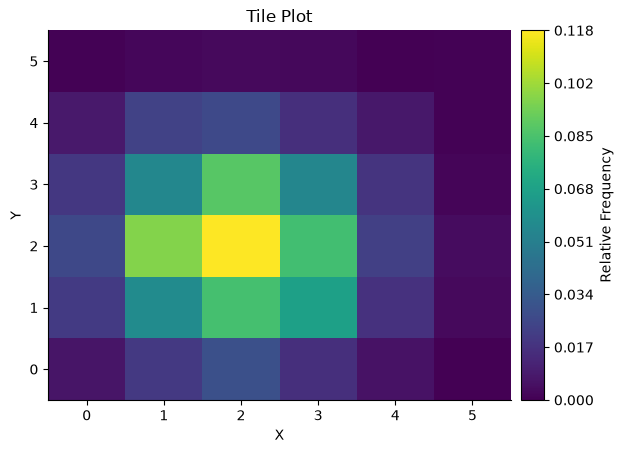

In [13]:
RV(Binomial(5, 0.4) * Binomial(5, 0.4)).sim(2000).plot(suggest=True)

**Alternative** (`mosaic`; `scatter` and `tile` are the defaults above)

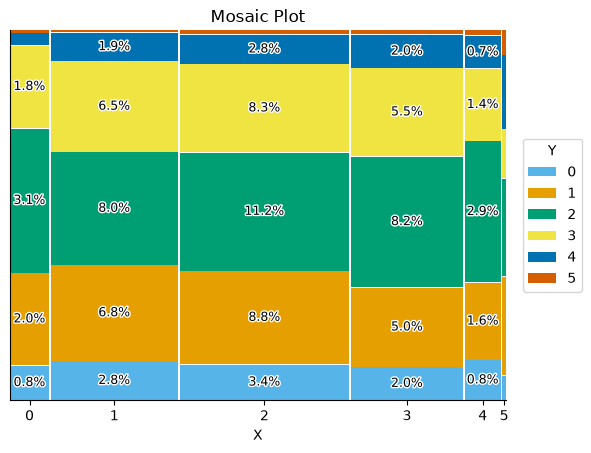

In [14]:
RV(Binomial(5, 0.4) * Binomial(5, 0.4)).sim(2000).plot(type="mosaic")

## 2D continuous × continuous

Two continuous variables, e.g. `Normal(0, 1) * Normal(0, 1)`. The default is
a **scatter** at small `n` and a **2D histogram** at large `n`.

**Small `n` → scatter (default)**

Currently Showing: Scatter Plot (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), 2D Histogram (type = "hist2d")


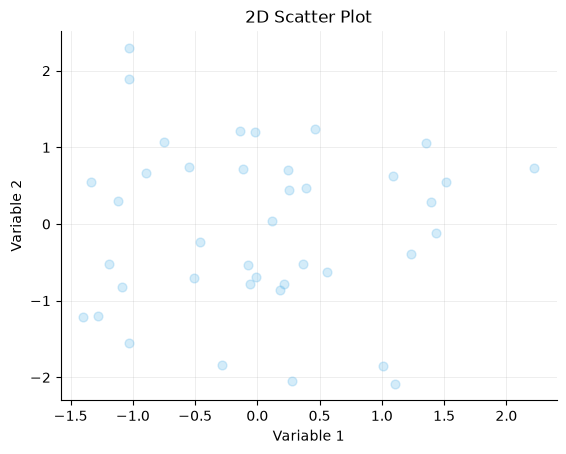

In [15]:
RV(Normal(0, 1) * Normal(0, 1)).sim(40).plot(suggest=True)

**Large `n` → 2D histogram (default)**

Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


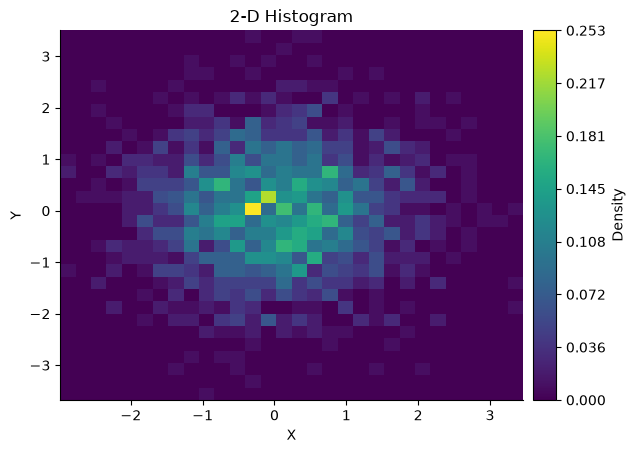

In [16]:
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(suggest=True)

**Alternative** (`density2d`; `scatter` and `hist2d` are the defaults above)

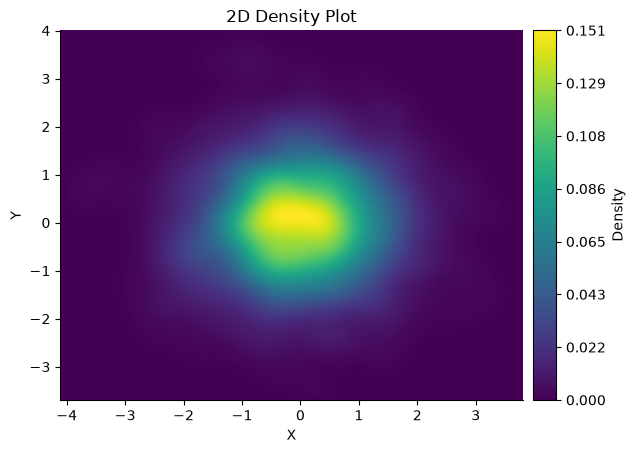

In [17]:
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(type="density2d")

## 2D mixed (discrete × continuous)

One discrete and one continuous variable, e.g.
`Binomial(5, 0.4) * Normal(0, 1)`. The default is a **segmented rug** at
small `n` (individual ticks grouped by the discrete level) and a **tile
plot** at large `n`.

**Small `n` → segmented rug (default)**

Currently Showing: Segmented Rug Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Box Plot (type = "box"), Violin Plot (type = "violin"), Segmented Density Plot (type = "segmented_density")


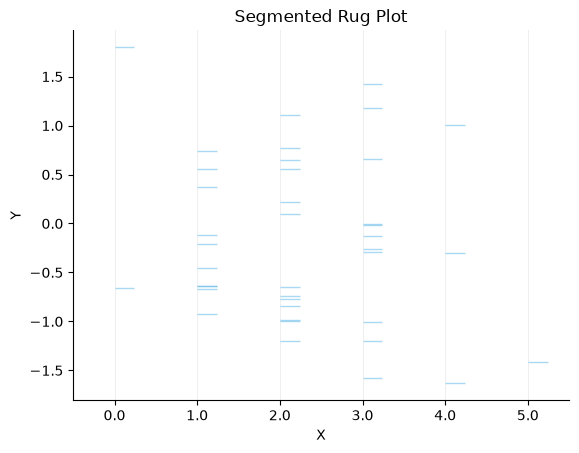

In [18]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(40).plot(suggest=True)

**Large `n` → tile plot (default)**

Currently Showing: Tile Plot (Default)
Alternative Plots: Violin Plot (type = "violin"), Box Plot (type = "box"), Segmented Density Plot (type = "segmented_density")


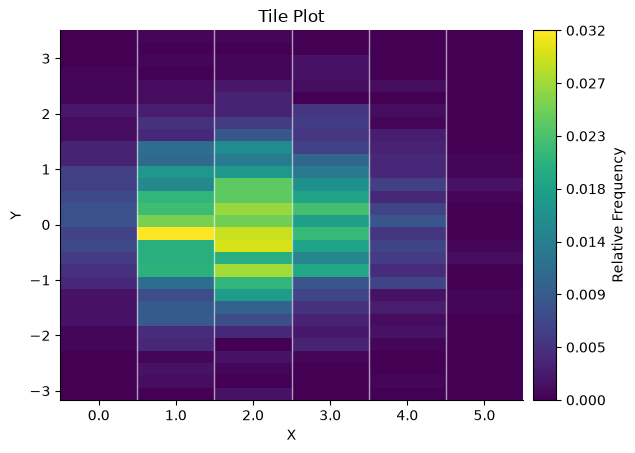

In [19]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(suggest=True)

**Alternatives** (`box`, `violin`, `segmented_density`; `segmented_rug` and `tile` are the defaults above)

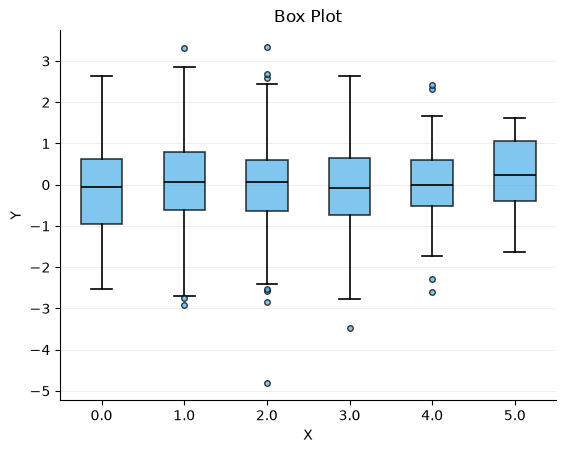

In [20]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type="box")

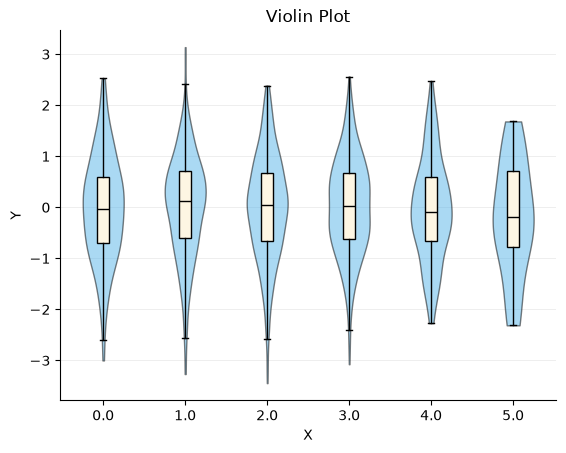

In [21]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type="violin")

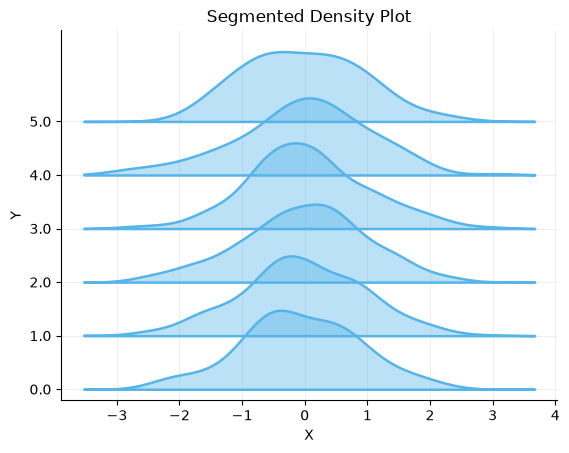

In [22]:
# Discrete variable second (on y) -> the classic ridgeline look:
# horizontal density ridges stacked vertically. With the discrete
# variable on x, the ridges stand vertically instead, mirroring the
# segmented rug.
RV(Normal(0, 1) * Binomial(5, 0.4)).sim(2000).plot(type="segmented_density")

## Recap

- `.plot()` chooses a default from the **data configuration** and **sample
  size**; the default often shifts as `n` grows (e.g. dot plot → impulse,
  rug → histogram, scatter → tile / 2D histogram).
- Any listed **alternative** can be requested with `type="..."`.
- The note under a default plot (shown with `suggest=True`) always tells you
  the current plot and the alternatives for that data; pass `suggest=False`
  to silence it.